In [1]:
# 1. Prepare features and target

import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Load clean dataset
penguins_clean = pd.read_csv('./penguins_clean.csv')

# Encode species (categorical) and target (sex)
# LabelEncoder convert categorical labels into numerical values.
# It assigns a unique integer to each unique label, transforming the labels into a format that can be processed by machine learning algorithms.
le_species = LabelEncoder() 
le_sex = LabelEncoder() 

df = penguins_clean.copy()

df['species_enc'] = le_species.fit_transform(df['species'])
df['sex_enc'] = le_sex.fit_transform(df['sex'])  # female = 0, male = 1

# Feature selection
feature_cols = [
    'bill_length_mm',
    'bill_depth_mm',
    'flipper_length_mm',
    'body_mass_g',
    'species_enc'
]

X = df[feature_cols]
y = df['sex_enc']

print("Feature matrix shape:", X.shape)
print("Target distribution:\n", y.value_counts().rename(index={0: 'female', 1: 'male'}))

Feature matrix shape: (333, 5)
Target distribution:
 sex_enc
male      168
female    165
Name: count, dtype: int64


In [2]:
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,species_enc,sex_enc
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,0,1
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,0,0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,0,0
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,0,0
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male,0,1
...,...,...,...,...,...,...,...,...,...
328,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female,2,0
329,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female,2,0
330,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male,2,1
331,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female,2,0


In [3]:
# 2. Train / test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# Stratify - “Split the data so that the train and test sets keep the same class proportions as the original target.”
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 266 rows | Test: 67 rows


In [19]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import GradientBoostingClassifier

pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('clf', GradientBoostingClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=2,
        subsample=0.8,
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)
print("Pipeline fitted with RobustScaler + Gradient Boosting.")


Pipeline fitted with RobustScaler + Gradient Boosting.


              precision    recall  f1-score   support

      Female       0.97      0.88      0.92        33
        Male       0.89      0.97      0.93        34

    accuracy                           0.93        67
   macro avg       0.93      0.92      0.93        67
weighted avg       0.93      0.93      0.93        67



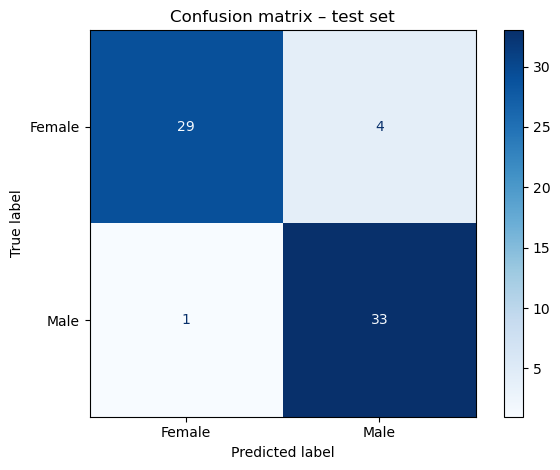

In [20]:
# 4. Evaluate on the held-out test set

y_pred = pipeline.predict(X_test)

print(classification_report(
    y_test,
    y_pred,
    target_names=le_sex.classes_
))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le_sex.classes_
)

disp.plot(cmap='Blues')
plt.title('Confusion matrix – test set')
plt.tight_layout()
plt.show()


In [21]:
# 5. Stratified 5-fold cross-validation (full clean dataset)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring='accuracy'
)

print(f"CV scores: {cv_scores.round(3)}")
print(f"Mean: {cv_scores.mean():.3f}")
print(f"Std:  {cv_scores.std():.3f}")

CV scores: [0.765 0.941 0.941 0.939 0.879 0.788 0.97  0.909 1.    0.97 ]
Mean: 0.910
Std:  0.074


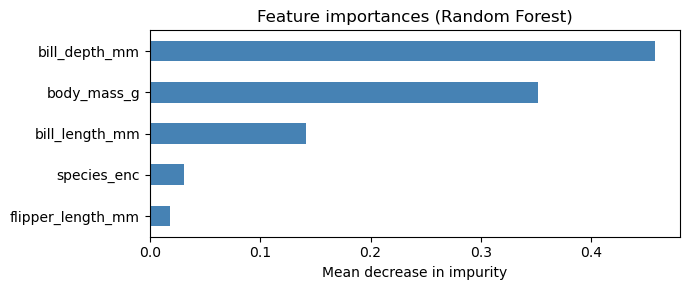

In [22]:
# 6. Feature importances

importances = pipeline.named_steps['clf'].feature_importances_

feat_imp = pd.Series(
    importances,
    index=feature_cols
).sort_values(ascending=True)

feat_imp.plot(
    kind='barh',
    color='steelblue',
    figsize=(7, 3)
)

plt.title('Feature importances (Random Forest)')
plt.xlabel('Mean decrease in impurity')
plt.tight_layout()
plt.show()


In [23]:
# 7. Predict sex for the 9 unknown rows

# Encode species in the unknown-sex df using the same fitted encoder
penguins_unknown_sex = pd.read_csv('./penguins_unknown_sex.csv')

unknown = penguins_unknown_sex.copy()
unknown['species_enc'] = le_species.transform(unknown['species'])

X_unknown = unknown[feature_cols]

predicted_encoded = pipeline.predict(X_unknown)
predicted_proba = pipeline.predict_proba(X_unknown)

unknown['predicted_sex'] = le_sex.inverse_transform(predicted_encoded)
unknown['confidence'] = predicted_proba.max(axis=1).round(3)

result_cols = [
    'species',
    'island',
    'bill_length_mm',
    'bill_depth_mm',
    'flipper_length_mm',
    'body_mass_g',
    'predicted_sex',
    'confidence'
]

print(unknown[result_cols].to_string(index=True))


  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g predicted_sex  confidence
0  Adelie  Torgersen            34.1           18.1              193.0       3475.0        Female       0.987
1  Adelie  Torgersen            42.0           20.2              190.0       4250.0          Male       1.000
2  Adelie  Torgersen            37.8           17.1              186.0       3300.0        Female       0.998
3  Adelie  Torgersen            37.8           17.3              180.0       3700.0        Female       0.910
4  Adelie      Dream            37.5           18.9              179.0       2975.0        Female       0.981
5  Gentoo     Biscoe            44.5           14.3              216.0       4100.0        Female       0.998
6  Gentoo     Biscoe            46.2           14.4              214.0       4650.0        Female       0.999
7  Gentoo     Biscoe            47.3           13.8              216.0       4725.0        Female       0.999
8  Gentoo 

In [10]:
df.groupby(['species', 'sex'])[['body_mass_g', 'bill_depth_mm']].mean()

body_mass_g  bill_depth_mm
species   sex                               
Adelie    Female  3368.835616      17.621918
          Male    4043.493151      19.072603
Chinstrap Female  3527.205882      17.588235
          Male    3938.970588      19.252941
Gentoo    Female  4679.741379      14.237931
          Male    5484.836066      15.718033

In [11]:
# Combine clean dataset with the 9 now-predicted rows

unknown_filled = penguins_unknown_sex.copy()
unknown_filled['sex'] = unknown['predicted_sex']

penguins_full = pd.concat(
    [penguins_clean, unknown_filled],
    ignore_index=True
)

print(f"penguins_clean: {penguins_clean.shape[0]} rows")
print(f"unknown rows:   {unknown_filled.shape[0]} rows")
print(f"penguins_full:  {penguins_full.shape[0]} rows")
print(f"\nNull counts:\n{penguins_full.isnull().sum()}")

penguins_clean: 333 rows
unknown rows:   9 rows
penguins_full:  342 rows

Null counts:
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


In [12]:
penguins_full.to_csv('./data/penguins_full.csv', index=False)

In [13]:
penguins_clean['sex'].value_counts()

sex
Male      168
Female    165
Name: count, dtype: int64